# Multi-agent collaboration on GSM8K: original experiment notebook

This is the notebook that produced the results in `results/` and the report in `report/`, kept with its outputs as the experiment record.

Edits made for publication, each marked in place with `[portfolio repo edit]`: a hard-coded home directory was replaced with `~`, repeated progress lines and progress-bar widgets from the 200-question sweep were removed (the summary table is kept), Metal backend warnings were shortened, and the traceback from a demo stopped by hand was replaced with a note. Code cells and all results, tables and figures are unchanged.

Its first sections started from the course's Colab starter template (Hugging Face transformers on a T4 GPU). The experiment ran locally with llama-cpp-python on an M1 Pro, so the Colab cells are skipped at runtime.

For a reusable version, use the `multiagent_math` package and the `mam` command described in the README.

LOCAL ONLY VARIABLE

In [1]:
# [LOCAL RUNTIME] — llama-cpp-python IN-PROCESS on M1 Pro

import os, platform, json
from typing import List, Dict, Any

MODEL_PATH = os.path.expanduser(
    "~/models/qwen2.5-7b-instruct-q4_k_m-00001-of-00002.gguf"
)

assert os.path.exists(MODEL_PATH), f"Model file not found: {MODEL_PATH}"

print("Local GGUF model:", MODEL_PATH)
print("Python:", platform.python_version(), "-", platform.system(), platform.machine())

_LOCAL = {"llm": None}

def _ensure_llm_loaded():
    """Load the GGUF model once per kernel."""
    if _LOCAL["llm"] is None:
        from llama_cpp import Llama
        _LOCAL["llm"] = Llama(
            model_path=MODEL_PATH,
            n_gpu_layers=999,
            n_ctx=4096,
            n_batch=512,
            chat_format="qwen",   # lets llama.cpp format Qwen chat
            verbose=False,
        )
    return _LOCAL["llm"]

Local GGUF model: ~/models/qwen2.5-7b-instruct-q4_k_m-00001-of-00002.gguf
Python: 3.12.0 - Darwin arm64


## 1. 🛠️ Setup and Installation

First, we need to install the necessary libraries from the Hugging Face ecosystem.

-   `transformers`: For loading models and tokenizers.
-   `torch`: The core deep learning framework.
-   `accelerate`: To help run models on our hardware efficiently.
-   `bitsandbytes`: For performing model quantization (loading the model in 4-bit precision) to save memory.

In [2]:
if platform.system() == "Linux" and "COLAB_GPU" in os.environ:
    # We're in Colab
    !pip install -Uq --index-url https://download.pytorch.org/whl/cu126 \
      torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0
    !pip install -Uq "transformers>=4.44,<5" "accelerate>=1.0.0" bitsandbytes
else:
    print("Skipping PyTorch installation — local GGUF mode.")

Skipping PyTorch installation — local GGUF mode.


## 2. 🧠 Model Loading and Configuration

Here, we'll load the `Qwen2.5-7B-Instruct` model from the Hugging Face Hub. To make it fit within the T4 GPU's ~16GB of VRAM, we will use **4-bit quantization**. This dramatically reduces the model's memory footprint with a minimal impact on performance for many tasks.

In [3]:

# If running in Colab + GPU → use HF transformers model
if platform.system() == "Linux" and "COLAB_GPU" in os.environ:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    model_id = "Qwen/Qwen2.5-7B-Instruct"
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
    )

    tokenizer = AutoTokenizer.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=quantization_config,
        device_map="auto",
    )

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model.eval()
else:
    print("Skipping HF transformers model load — local GGUF mode.")

Skipping HF transformers model load — local GGUF mode.


# Check the model template


Here we will print the template the model uses and understand how me must interact with it.

In [ ]:
# Preview the way the model receives the messages

messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Who are you?"}
]
preview = tokenizer.apply_chat_template(
    messages,
    add_generation_prompt=True,   # appends the assistant prefix so model knows to answer
    tokenize=False                # return a string so you can inspect it
)

print(f'Preview: \n\n' + preview)

### Create a Generation Pipeline

To make interacting with the model easier, let's create a helper function. This function will take a prompt, format it correctly for the Mistral Instruct model, and generate a response.

It may also take parameters such as: *temperature, max_new_tokens, top_p, top_k*, and *system_instructions*.



The quickstart guide to the model in Hugging Face was partially used in this implementation.

Link to the guide: https://huggingface.co/Qwen/Qwen2.5-7B-Instruct


In [4]:
def generate_response(
    prompt: str,
    max_new_tokens: int = 256,
    temperature: float = 0.7,
    top_p: float = 0.95,
    top_k: int = 50,
    system_instructions: str = "",
) -> str:
    """
    Local version: generates a response from the GGUF model via llama-cpp.

    Signature is kept identical to the Colab version so all existing
    agents can keep calling generate_response(...) without changes.
    """

    llm = _ensure_llm_loaded()

    # Build messages exactly like before, but now for chat_format="qwen2"
    if system_instructions == "":
        messages = [
            {"role": "user", "content": prompt}
        ]
    else:
        messages = [
            {"role": "system", "content": system_instructions},
            {"role": "user", "content": prompt},
        ]

    args = {
        "messages": messages,
        "temperature": float(temperature),
        "top_p": float(top_p),
        "max_tokens": int(max_new_tokens),
        "stream": False,
    }
    if top_k is not None:
        args["top_k"] = int(top_k)

    # llama-cpp handles sampling; no torch / tokenizer here
    out = llm.create_chat_completion(**args)
    response = out["choices"][0]["message"]["content"].strip()
    return response

In [5]:
test = generate_response("What is 2 + 2?", max_new_tokens=16)

print("Test response:", test)

llama_context: n_ctx_per_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized
[portfolio repo edit] further Metal kernel warnings removed


Test response: 2 + 2 equals 4.


### Defining Agent Roles and Helper Functions  

This block defines each agent of the project: **Proposer**, **Critic**, and **Refiner**.  
Each agent is essentially a specialized prompt that instructs the same underlying language model to perform a different role in the reasoning process.  
Together, they form a multi-stage pipeline that allows the model to first **propose**, then **evaluate**, and finally **refine** a solution.

- **Agent 1: The Proposer**  
  Generates an initial, detailed response or solution to the given input. It is responsible for outlining the first approach to the task, setting the foundation for later review.

- **Agent 2: The Critic**  
  Reviews the Proposer’s output, identifying potential flaws, logical errors, or areas for improvement. It acts as a verifier that challenges and strengthens the reasoning.

- **Agent 3: The Refiner**  
  Receives the original task, the Proposer’s answer, and the Critic’s feedback, and produces a final, improved version that integrates the necessary corrections or clarifications.

Two specialized sets of these agents are introduced below, each using the same core architecture but adapting tone and structure to different kinds of problems:


### Mathematical Problem Agents

This set is designed for exercises that require **structured reasoning and precision**.  
The prompts guide the model through analytical steps, encourage clarity in logical flow, and emphasize accuracy in intermediate and final results.  
Each stage (proposal, critique, and refinement) is oriented toward obtaining a clear, correct solution through concise yet rigorous reasoning.

In [6]:
def math_proposer_agent(task, max_tokens=256):
    """
    The Proposer Agent: Generates an initial, step-by-step solution.
    """
    prompt = f"""
    You are the Proposer Agent. Your role is to analyze the following excercise and provide a clear solution.
    Provide your step by step thoughts in a concise manner. Do not over explain.

    At the end, write the final numeric answer on a single line in this format:
    #### <number>

    Excercise: {task}

    Provide your proposed solution below:
    """
    print("--- PROPOSER AGENT WORKING ---")
    return generate_response(prompt, max_new_tokens=max_tokens)

def math_critic_agent(task,proposed_solution,max_tokens=256):
    """
    The Critic Agent: Reviews a solution and provides constructive feedback.
    """
    prompt = f"""
    You are a Critic Agent. Your role is to meticulously but concisely review the proposed solution for the given excercise.
    Identify any potential flaws, logical errors, missed assumptions, or areas for improvement.
    Do not provide a new solution.
    If the Proposer's Solution is correct provide insight about the solution.
    If not completely correct analyze it and provide insight.

    Original Exercise: {task}
    Proposed Solution to review:
    ---
    {proposed_solution}
    ---

    Provide your critical analysis below:
    """
    print("\n--- CRITIC AGENT WORKING ---")
    return generate_response(prompt, max_new_tokens=max_tokens)

def math_refiner_agent(task, proposed_solution, critique, max_tokens=512):
    """
    The Refiner Agent: Takes a proposal and a critique to generate a final, improved solution.
    """
    prompt = f"""
    You are the Refiner Agent. Your role is to produce a final, correct solution to a task using an initial proposal and a critique of that proposal.
    Carefully consider the critique and use it to fix the flaws in the original proposal if any.

    Original Task: {task}

    Proposed Solution:
    ---
    {proposed_solution}
    ---

    Critique of the Solution:
    ---
    {critique}
    ---

    Based on the critique, provide the final, corrected solution below. Explain your steps clearly.
    At the end, write the final numeric answer on a single line exactly like:
    #### <number>
    No words or units after the hashes.

    """
    print("\\n--- REFINER AGENT WORKING ---")
    return generate_response(prompt, max_new_tokens=max_tokens)

### Testing the Mathematical Agents  

This section demonstrates the behavior of the **Mathematical / Logical Agents** through two short examples.  
The goal is to illustrate how the **Proposer -> Critic -> Refiner** workflow functions on problems of increasing complexity.

- **Test 1** presents a simple arithmetic exercise to confirm that the agents handle straightforward computations correctly.  
- **Test 2** introduces a multi-step, GSM8K-style reasoning problem that requires combining multiple operations and unit conversions.  

These examples serve to validate that each agent performs its role as intended — the *Proposer* generates an initial reasoning chain, the *Critic* evaluates its correctness, and the *Refiner* integrates the feedback into a final, polished solution.

In [7]:
# ==========================================
# Testing the Mathematical Agents
# ==========================================

# Test 1: Simple arithmetic problem
simple_task = "Compute 5 × 10 + 7."

print("\n==============================")
print("  SIMPLE MATHEMATICAL TEST")
print("==============================")

# Proposer
simple_proposal = math_proposer_agent(simple_task)
print("\n[PROPOSER OUTPUT]")
print(simple_proposal)

# Critic
simple_critique = math_critic_agent(simple_task, simple_proposal)
print("\n[CRITIC OUTPUT]")
print(simple_critique)

# Refiner
simple_final = math_refiner_agent(simple_task, simple_proposal, simple_critique)
print("\n[REFINER OUTPUT]")
print(simple_final)


# Test 2: More complex reasoning problem
complex_task = """
A store is offering a 15% discount on all items.
If an item originally costs $80 and there is an additional 8% sales tax applied after the discount,
what is the final price the customer pays?
"""

print("\n==============================")
print(" COMPLEX MATHEMATICAL TEST")
print("==============================")

# Proposer
complex_proposal = math_proposer_agent(complex_task)
print("\n[PROPOSER OUTPUT]")
print(complex_proposal)

# Critic
complex_critique = math_critic_agent(complex_task, complex_proposal)
print("\n[CRITIC OUTPUT]")
print(complex_critique)

# Refiner
complex_final = math_refiner_agent(complex_task, complex_proposal, complex_critique)
print("\n[REFINER OUTPUT]")
print(complex_final)


  SIMPLE MATHEMATICAL TEST
--- PROPOSER AGENT WORKING ---

[PROPOSER OUTPUT]
#### 57

--- CRITIC AGENT WORKING ---

[CRITIC OUTPUT]
The proposed solution of **57** is incorrect. The correct computation for the expression \(5 \times 10 + 7\) should be:

\[5 \times 10 = 50\]
\[50 + 7 = 57\]

However, the proposed answer of **57** is actually the result of the computation, not the solution itself. The mistake here is that the solution should have shown the steps or the correct intermediate result, but instead, it simply provided the final number without any context or explanation.

A more appropriate and concise review would be:

\[5 \times 10 = 50\]
\[50 + 7 = 57\]

The correct final answer is **57**, but the steps should be clearly shown to demonstrate the proper calculation process.
\n--- REFINER AGENT WORKING ---

[REFINER OUTPUT]
#### 57

Steps:
\[5 \times 10 = 50\]
\[50 + 7 = 57\]

 COMPLEX MATHEMATICAL TEST
--- PROPOSER AGENT WORKING ---

[PROPOSER OUTPUT]
1. Calculate the discoun

### Complex-Task / Planning Agents  
This set targets **broader, open ended problems** that involve planning, synthesis, or coordination of multiple steps.  
Here, the agents focus on generating organized, coherent reasoning, highlighting dependencies or potential conflicts in the solutions, and refining the plan into a practical, well-structured outcome.  
The overall structure remains the same, but the prompts allow for a more flexible, exploratory reasoning process suited to complex tasks that are not strictlly mathematical.

In [8]:
def complex_proposer_agent(task, max_tokens=512):
    """
    The Proposer Agent: Generates an initial, step-by-step solution.
    """
    prompt = f"""
    You are the Proposer Agent. Your role is to analyze the following task and provide a clear, step-by-step solution.
    Be concise but informative about your reasoning.

    Task: {task}

    Provide your proposed solution below:
    """
    print("--- PROPOSER AGENT WORKING ---")
    return generate_response(prompt, max_new_tokens=max_tokens)

def complex_critic_agent(task, proposed_solution, max_tokens=512):
    """
    The Critic Agent: Reviews a solution and provides constructive feedback.
    """
    prompt = f"""
    You are the Critic Agent. Your role is to meticulously review the proposed solution for the given task.
    Identify any potential flaws, logical errors, missed assumptions, or areas for improvement.
    Do not provide a new solution, only critique the existing one and bring up how it could be improved.
    Be concise but informative.

    Original Task: {task}
    Proposed Solution to review:
    ---
    {proposed_solution}
    ---

    Provide your critical analysis below:
    """
    print("\n--- CRITIC AGENT WORKING ---")
    return generate_response(prompt, max_new_tokens=max_tokens)

def complex_refiner_agent(task, proposed_solution, critique, max_tokens=1024):
    """
    The Refiner Agent: Takes a proposal and a critique to generate a final, improved solution.
    """
    prompt = f"""
    You are the Refiner Agent. Your role is to produce a final, correct solution to a task using an initial proposal and a critique of that proposal.
    Carefully consider the critique and use it to fix the flaws in the original proposal.

    Original Task: {task}

    Proposed Solution:
    ---
    {proposed_solution}
    ---

    Critique of the Solution:
    ---
    {critique}
    ---

    Based on the critique, provide the final, corrected solution below. Explain your steps concisely.
    """
    print("\\n--- REFINER AGENT WORKING ---")
    return generate_response(prompt, max_new_tokens=max_tokens)

### Testing the Complex-Task Agents  

This section showcases the **Complex Task / Planning Agents** using two illustrative examples.  
The objective is to demonstrate how the **Proposer -> Critic -> Refiner** sequence operates in broader, open ended reasoning tasks where structure, organization, and synthesis matter more than exact numerical accuracy.

- **Test 1** involves a short planning or procedural task, showing how the agents build, review, and refine a clear step-by-step approach.  
- **Test 2** presents a more complex scenario that requires balancing different considerations or resources, allowing the Critic and Refiner to highlight and resolve inconsistencies.  

These demonstrations make apparent how the complex task workflow supports coherent, well-structured reasoning, useful for planning, analysis, or creative synthesis beyond purely mathematical settings and a more "real-world" actions setting.

In [9]:
# ==========================================
# Testing the Complex-Task / Planning Agents
# ==========================================

# Test 1: Short planning/procedural task
ct_simple_task = """
Plan a 90-minute study block for Linear Algebra focused on:
- eigenvalues/eigenvectors
- SVD (basics)
"""

print("\n==============================")
print("  COMPLEX TASK TEST — SHORT PLAN")
print("==============================")

# Proposer
ct_simple_proposal = complex_proposer_agent(ct_simple_task)
print("\n[PROPOSER OUTPUT]")
print(ct_simple_proposal)

# Critic
ct_simple_critique = complex_critic_agent(ct_simple_task, ct_simple_proposal)
print("\n[CRITIC OUTPUT]")
print(ct_simple_critique)

# Refiner
ct_simple_final = complex_refiner_agent(ct_simple_task, ct_simple_proposal, ct_simple_critique)
print("\n[REFINER OUTPUT]")
print(ct_simple_final)



  COMPLEX TASK TEST — SHORT PLAN
--- PROPOSER AGENT WORKING ---

[PROPOSER OUTPUT]
### Proposed Solution for 90-Minute Study Block on Linear Algebra

#### Step-by-Step Breakdown:

1. **Introduction (5 minutes)**
   - Briefly introduce the importance of eigenvalues/eigenvectors and SVD in linear algebra.
   - Mention their applications in data science, machine learning, and other fields.

2. **Eigenvalues and Eigenvectors (20 minutes)**
   - **Definition and Properties (10 minutes)**
     - Define eigenvalues and eigenvectors.
     - Explain the characteristic equation and how to find eigenvalues.
     - Discuss the geometric interpretation and properties of eigenvectors.
   - **Example Calculation (10 minutes)**
     - Provide a simple 2x2 matrix and walk through the process of finding its eigenvalues and eigenvectors.
     - Discuss the significance of eigenvalues (real, complex, positive, negative).

3. **SVD (Singular Value Decomposition) Basics (30 minutes)**
   - **Definition and

In [10]:
#Test 2: Planning a 2 Day student budget city visit.
ct_complex_task = """
Plan a 2-day student-budget city visit in a city of your preference.

Requirements:
- Include 4 free or low-cost highlights each day
- Use public transit only, note transit lines or walking times
- 3 meals/day with an estimated daily food budget of less than $40
- Daily step target: about 12,000
- Hours: start at 09:00, finish by 20:00
"""

print("\n==============================")
print("  COMPLEX TASK TEST — 2-DAY STUDENT ITINERARY")
print("==============================")

# Proposer
ct_complex_proposal = complex_proposer_agent(ct_complex_task)
print("\n[PROPOSER OUTPUT]")
print(ct_complex_proposal)

# Critic
ct_complex_critique = complex_critic_agent(ct_complex_task, ct_complex_proposal)
print("\n[CRITIC OUTPUT]")
print(ct_complex_critique)

# Refiner
ct_complex_final = complex_refiner_agent(ct_complex_task, ct_complex_proposal, ct_complex_critique)
print("\n[REFINER OUTPUT]")
print(ct_complex_final)


  COMPLEX TASK TEST — 2-DAY STUDENT ITINERARY
--- PROPOSER AGENT WORKING ---

[PROPOSER OUTPUT]
**Proposed Solution: 2-Day Student-Budget City Visit in Boston, MA**

**Day 1:**

1. **09:00 - 10:30 AM: Boston Public Garden & Mugar Memorial Fountain**
   - Walk from the nearest T station (Downtown) to the Boston Public Garden, about 15-20 minutes.
   - Free admission.
   - Explore the gardens and fountain, enjoy the park's beauty and free Wi-Fi.

2. **10:30 - 12:00 PM: The Boston Common & Park**
   - From the Boston Public Garden, walk to the Boston Common (about 5-10 minutes).
   - Free admission.
   - Visit the historic park, enjoy the open spaces, and feed the ducks.

3. **12:00 - 13:00 PM: Free Lunch at the Boston Common**
   - Head to the nearby "Three on the Common" for a free lunch (bring your own or use local food trucks).
   - Estimated cost: $0.

4. **13:00 - 14:30 PM: The Freedom Trail**
   - Walk the Freedom Trail from the Boston Common to the Old State House (about 30-40 mi

## Establishing the Single Agent Baseline.

To evaluate if the multi-agent approach is better, we need a **single-agent baseline**. This is simply the answer from one agent working alone without any review or refinement.

In [11]:
def single_agent_baseline(task):
    """
    A single agent trying to solve the task directly.
    """
    prompt = f"""
    You are an AI assistant. Solve the following task, providing your final answer and reasoning in a concise but informative manner.

    Task: {task}
    """
    print("--- SINGLE-AGENT BASELINE WORKING ---")
    return generate_response(prompt, max_new_tokens=256)

### Single-Agent Baseline (Demonstration)

This block runs a **single-agent** version of the workflow on the same four examples used above:
1) Simple arithmetic  
2) GSM8K-style multi-step math  
3) Short planning/procedural task  
4) Two-day student itinerary

Purpose: provide a plain, one-shot reference to compare against the multi-agent **Proposer -> Critic -> Refiner** pipeline in terms of clarity, correctness, and verbosity. The baseline uses the same underlying model but **no intermediate roles**.

In [12]:
# ============================================
# Single-Agent Baseline — Comparison Examples
# ============================================

# ---- Tasks (same content as in the earlier demos) ----

# Math 1: Simple arithmetic
simple_math_task = "Compute 5 × 10 + 7."

# Math 2: GSM8K like multi-step reasoning
gsm_like_math_task = """
A factory produces 120 widgets every hour.
Each widget requires 3 screws.
The factory operates 8 hours per day, 5 days per week.
If each box of screws contains 360 screws,
how many boxes of screws are needed to support one week of production?
"""

# ---- Runs ----

print("\n==============================")
print("  BASELINE — SIMPLE MATH")
print("==============================")
baseline_simple_math = single_agent_baseline(simple_math_task)
print("\n[BASELINE OUTPUT]")
print(baseline_simple_math)


print("\n==============================")
print("  BASELINE — GSM8K LIKE MATH")
print("==============================")
baseline_gsm_like = single_agent_baseline(gsm_like_math_task)
print("\n[BASELINE OUTPUT]")
print(baseline_gsm_like)


  BASELINE — SIMPLE MATH
--- SINGLE-AGENT BASELINE WORKING ---

[BASELINE OUTPUT]
Final answer: 57

Reasoning: According to the order of operations (PEMDAS/BODMAS), we perform multiplication before addition. So, we first compute 5 × 10, which equals 50. Then we add 7 to get 57.

  BASELINE — GSM8K LIKE MATH
--- SINGLE-AGENT BASELINE WORKING ---

[BASELINE OUTPUT]
To solve this problem, let's break it down step-by-step:

1. **Widgets produced in one week:**
   - Widgets per hour: 120
   - Hours per day: 8
   - Days per week: 5
   - Widgets per week = 120 widgets/hour * 8 hours/day * 5 days/week = 4800 widgets

2. **Screws required for one week:**
   - Screws per widget: 3
   - Total screws = 4800 widgets * 3 screws/widget = 14400 screws

3. **Boxes of screws needed:**
   - Screws per box: 360
   - Boxes needed = 14400 screws / 360 screws/box = 40 boxes

Therefore, the factory needs 40 boxes of screws to support one week of production.


In [13]:
# Complex Task 1: Short planning/procedural task
ct_simple_task = """
Plan a 90-minute study block for Linear Algebra focused on:
- eigenvalues/eigenvectors
- SVD (basics)
"""

# Complex Task 2: Two-day student itinerary (less technical, multi-constraint)
ct_complex_task = """
Plan a 2-day student-budget city visit.
Requirements:
- Include 4 free or low-cost highlights each day
- Use public transit only; note transit lines or walking times
- 3 meals/day with an estimated daily food budget ≤ $35
- Daily step target: ~12,000
- Hours: start at 09:00, finish by 20:00
"""

# ---- Runs ----

print("\n==============================")
print("  BASELINE — SHORT PLAN")
print("==============================")
baseline_ct_simple = single_agent_baseline(ct_simple_task)
print("\n[BASELINE OUTPUT]")
print(baseline_ct_simple)


print("\n==============================")
print("  BASELINE — 2-DAY ITINERARY")
print("==============================")
baseline_ct_complex = single_agent_baseline(ct_complex_task)
print("\n[BASELINE OUTPUT]")
print(baseline_ct_complex)



  BASELINE — SHORT PLAN
--- SINGLE-AGENT BASELINE WORKING ---

[BASELINE OUTPUT]
**90-Minute Study Block Plan for Linear Algebra:**

**Duration:** 90 minutes

**1. Introduction (10 minutes)**
- Brief overview of eigenvalues/eigenvectors and SVD.
- Importance in data science and engineering.

**2. Eigenvalues/Eigenvectors (25 minutes)**
- Definition and geometric interpretation.
- Finding eigenvalues and eigenvectors (examples).
- Properties and applications (e.g., stability of systems).

**3. Eigendecomposition (10 minutes)**
- How to decompose a matrix into its eigenvalues and eigenvectors.
- Practical examples and computational methods.

**4. Singular Value Decomposition (20 minutes)**
- Definition and geometric interpretation.
- Basic properties and how it differs from eigendecomposition.
- Example: SVD of a 2x2 matrix.

**5. Applications of SVD (10 minutes)**
- Data compression.
- Image processing.
- Recommender systems.

**6. Review and Practice (5 minutes)**
- Quick review of ke

##  Analysis of the demonstration examples

### 1 Mathematical / Logical Tasks  

#### **Simple Arithmetic Test**
For the simple problem (`5 × 10 + 7`), both the multi-agent and the baseline models reached the correct result.
The **Proposer -> Critic -> Refiner** pipeline mainly added verbosity — producing clear reasoning but no real improvement in correctness or actual
This leads to the fact the multi-agent setup introduces **overhead** on low-complexity computations, where the single-agent baseline is already optimal.

#### **GSM8K-Style Multi-Step Problem**
In the factory widgets example, the **Proposer** produced a coherent reasoning chain, while the **Critic** correctly verified multiplications and identified potential miscalculations.
The **Refiner** integrated these checks into a clean final solution matching the correct answer.
Compared to the baseline, the multi-agent system delivered a **more structured and understandable response**, demostrating its strength in more complex, step by step tasks.

**Summary:**  
Multi-agent reasoning seems to improve reliability and clarity for *multi-step quantitative logic*, but is redundant for *atomic arithmetic*.

---

### 2 Complex-Task / Planning Scenarios  

#### **Short Planning Task (90-min Study Block)**
The baseline produced a short generic timeline.  
The **Proposer** in the multi-agent chain expanded this into a more realistic and complete structure covering aspects more profoundlly (segments, practice phase, and closing summary).  
The **Critic** gave feedback on pacing and sequencing inconsistencies, and the **Refiner** integrated these, bringing a more balanced and coherent final proposal.
Here, collaboration clearly led to a **more coherent and pedagogically consistent plan**.

#### **Two-Day Student-Budget Itinerary**
This task had more requirements.
The **Proposer** generated an extensive itinerary; the **Critic** identified missing key points in budget breakdowns and weak assumptions about transit,  
the **Refiner** merged feedback to produce a structured plan with activities correctly lined up with the necessities of the task.
The single-agent baseline also created a plausible itinerary but lacked these refinements and had the overall first approach with more risk.

**Observation:**  
On open-ended tasks, the Critic behaves like a *reviewer or project planner*, turning generic drafts into robust, real world plans.

---

### 3 Overall Interpretation  

The experiments confirm that the **multi-agent architecture** is most beneficial when tasks involve:
- Multiple reasoning steps or intermediate implications.  
- Open ended outputs that need validation
- Contexts where self awareness matter more than response time.

In contrast, for single-operation or factual tasks, the **single-agent baseline remains preferable** due to its speed and simplicity.  
Eg. Math Simple Task.

This aligns with the initial hypothesis; where it is thought that collaborative prompting offers **marginal gains in accuracy** but **substantial gains in reasoning quality** on tasks with inherent complexity.

---

### 4 Next Steps  

- Extend evaluation to a real **GSM8K subset** for quantitative accuracy and latency benchmarking.  
- Log **token usage and runtime** per generation to analyze efficiency trade-offs in between the baseline and Multi agent architecture.
- Explore **multi-round debate** variants where the Critic can iterate before the Refiner finalizes the response.  
- Incorporate **automated parsing** of final answers for accuracy and timing data management.

## The Collaboration Workflow Function NOT USED AS OF NOW

This function will be used for the agents to collaborate on an automated manner, this will simplify the experimentation process in the future by offering a more iterable system.

The function will receive a prompt and problem type and will call the 3 corresponding agents in their respective order, generating the multi-agent response.


In [14]:
def math_multi_agent_response(task):
    """
    The multi-agent response should be generated from the Proposer -> Critic -> Refiner = Final response workflow using the
    math inclined functions.
    """

    # --- Step 1: Proposer generates its response
    proposed_solution = math_proposer_agent(task)
    print(f"\n[Proposer's Initial Solution]:\n{proposed_solution}")

    # --- Step 2: Critic gives feedback ---
    solution_critique = math_critic_agent(task, proposed_solution)
    print(f"\n[Critic's Analysis]:\n{solution_critique}")

    # --- Step 3: Refiner creates the final, synthezised response. ---
    final_solution = math_refiner_agent(task, proposed_solution, solution_critique)
    print(f"\n[Refiner's Final Synthezised Solution]:\n{final_solution}")


def complex_multi_agent_response(task):
    """
    The multi-agent response should be generated from the Proposer -> Critic -> Refiner = Final response workflow using the complex
    task inclined functions.
    """

    # --- Step 1: Proposer generates its response
    proposed_solution = complex_proposer_agent(task)
    print(f"\n[Proposer's Initial Solution]:\n{proposed_solution}")

    # --- Step 2: Critic gives feedback ---
    solution_critique = complex_critic_agent(task, proposed_solution)
    print(f"\n[Critic's Analysis]:\n{solution_critique}")

    # --- Step 3: Refiner creates the final, synthezised response. ---
    final_solution = complex_refiner_agent(task, proposed_solution, solution_critique)
    print(f"\n[Refiner's Final Synthezised Solution]:\n{final_solution}")

## Multi-Turn Collaboration Proposer -> Critic -> Refiner × Rounds

This section extends the single-turn pipeline into an iterative loop:
1) **Round t**: Proposer drafts -> Critic reviews -> Refiner integrates fixes.  
2) The Refiner’s output becomes the **proposal for the next round**.
3) Optional early stop if the Critic signals no issues.

We record **latency** and **token counts** per turn to study compute trade-offs vs. quality.

In [32]:
import time, re
import pandas as pd

def _count_tokens(text):
    """
    Token counting for llama_cpp model.
    Ensures text is a clean string and avoids HF tokenizer.
    """
    if text is None:
        return 0

    # Agents sometimes return tuples or other containers → convert safely
    if not isinstance(text, str):
        text = str(text)

    try:
        llm = _ensure_llm_loaded()
        # llama.cpp expects bytes → must encode
        toks = llm.tokenize(text.encode("utf-8"))
        return len(toks)
    except Exception as e:
        # Safe fallback: whitespace count
        return len(text.split())

# --- timer wrapper ----------------------------------------------
def _time_call(fn, *args, **kwargs):
    """Run a function and measure elapsed seconds."""
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    t1 = time.perf_counter()
    return out, (t1 - t0)


In [33]:
# ==============================================================
# MULTI-TURN LOOP: MATHEMATICAL / LOGICAL TASKS
# ==============================================================
def multi_turn_math_session(task, rounds=2, early_stop=True):
    """
    Iterates for 'rounds' through the workflow:

    Proposer -> Critic -> Refiner

    using the mathematically inclined agents. The Refiner's output becomes the next
    round's Proposer input.
    Returns a dict with transcripts and simple metrics.
    """

    transcripts = []          # per-round texts + per-round metrics
    total_latency = 0.0       # sum of seconds across all calls
    total_output_tokens = 0   # sum of tokens produced by agents

    # ---------- ROUND 1: normal flow ----------
    proposer_out, t_prop = _time_call(math_proposer_agent, task)
    critic_out,  t_crit = _time_call(math_critic_agent, task, proposer_out)
    refiner_out, t_ref  = _time_call(math_refiner_agent, task, proposer_out, critic_out)

    # bookkeeping for round 1
    r_tokens = _count_tokens(proposer_out) + _count_tokens(critic_out) + _count_tokens(refiner_out)
    r_latency = t_prop + t_crit + t_ref
    transcripts.append({
        "round": 1,
        "proposer": proposer_out,
        "critic": critic_out,
        "refiner": refiner_out,
        "latency_s": r_latency,
        "tokens_out": r_tokens,
    })
    total_latency += r_latency
    total_output_tokens += r_tokens

    # ---------- ROUNDS 2 -> R (optional) ----------
    current_prop = refiner_out  # refiner output becomes next proposal
    for r in range(2, rounds + 1):

        # proposer: reuse previous refiner output (no new generation)
        proposer_out = current_prop

        # critic + refiner
        critic_out,  t_crit = _time_call(math_critic_agent, task, proposer_out)
        refiner_out, t_ref  = _time_call(math_refiner_agent, task, proposer_out, critic_out)

        # bookkeeping
        r_tokens = _count_tokens(critic_out) + _count_tokens(refiner_out)
        r_latency = t_crit + t_ref
        transcripts.append({
            "round": r,
            "proposer": proposer_out,
            "critic": critic_out,
            "refiner": refiner_out,
            "latency_s": r_latency,
            "tokens_out": r_tokens,
        })
        total_latency += r_latency
        total_output_tokens += r_tokens

        # feed forward
        current_prop = refiner_out

    # final packaging
    return {
        "task": task.strip(),
        "rounds_run": transcripts[-1]["round"],
        "final_output": transcripts[-1]["refiner"],
        "transcript": transcripts,
        "total_latency_s": total_latency,
        "total_output_tokens": total_output_tokens,
    }

In [34]:
# ==============================================================
# MULTI-TURN LOOP: COMPLEX TASKS SESSION
# ==============================================================
def multi_turn_task_session(task, rounds=2, early_stop=True):
    """
    Same multi-turn loop but for complex/planning tasks, using:

    complex_proposer_agent / complex_critic_agent / complex_refiner_agent functions

    Structure is identical to the math session.
    """

    transcripts = []
    total_latency = 0.0
    total_output_tokens = 0

    # ---------- ROUND 1 ----------
    proposer_out, t_prop = _time_call(complex_proposer_agent, task)
    critic_out,  t_crit = _time_call(complex_critic_agent, task, proposer_out)
    refiner_out, t_ref  = _time_call(complex_refiner_agent, task, proposer_out, critic_out)

    r_tokens = _count_tokens(proposer_out) + _count_tokens(critic_out) + _count_tokens(refiner_out)
    r_latency = t_prop + t_crit + t_ref
    transcripts.append({
        "round": 1,
        "proposer": proposer_out,
        "critic": critic_out,
        "refiner": refiner_out,
        "latency_s": r_latency,
        "tokens_out": r_tokens,
    })
    total_latency += r_latency
    total_output_tokens += r_tokens

    # ---------- ROUNDS 2 -> R ----------
    current_prop = refiner_out
    for r in range(2, rounds + 1):

        proposer_out = current_prop
        critic_out,  t_crit = _time_call(complex_critic_agent, task, proposer_out)
        refiner_out, t_ref  = _time_call(complex_refiner_agent, task, proposer_out, critic_out)

        r_tokens = _count_tokens(critic_out) + _count_tokens(refiner_out)
        r_latency = t_crit + t_ref
        transcripts.append({
            "round": r,
            "proposer": proposer_out,
            "critic": critic_out,
            "refiner": refiner_out,
            "latency_s": r_latency,
            "tokens_out": r_tokens,
        })
        total_latency += r_latency
        total_output_tokens += r_tokens
        current_prop = refiner_out

    return {
        "task": task.strip(),
        "rounds_run": transcripts[-1]["round"],
        "final_output": transcripts[-1]["refiner"],
        "transcript": transcripts,
        "total_latency_s": total_latency,
        "total_output_tokens": total_output_tokens,
    }

In [35]:
# ==========================================
# DEMONSTRATION — MULTI-TURN FRAMEWORK
# ==========================================

# example 1: Simple mathematical task
math_simple_task = "Compute 5 × 10 + 7."

print("\n==============================")
print("  MULTI-TURN — SIMPLE MATH TEST")
print("==============================")

math_simple_result = multi_turn_math_session(math_simple_task, rounds=2, early_stop=True)
print(f"\nTotal Rounds: {math_simple_result['rounds_run']}")
print(f"Total Latency (s): {round(math_simple_result['total_latency_s'], 3)}")
print(f"Total Output Tokens: {math_simple_result['total_output_tokens']}")

for entry in math_simple_result["transcript"]:
    print(f"\n--- ROUND {entry['round']} ---")
    print("\n[PROPOSER OUTPUT]")
    print(entry["proposer"])
    print("\n[CRITIC OUTPUT]")
    print(entry["critic"])
    print("\n[REFINER OUTPUT]")
    print(entry["refiner"])


# example 2: GSM8K-style mathematical reasoning task
math_complex_task = """
A factory produces 120 widgets every hour.
Each widget requires 3 screws.
The factory operates 8 hours per day, 5 days per week.
If each box of screws contains 360 screws,
how many boxes of screws are needed to support one week of production?
"""

print("\n==============================")
print("  MULTI-TURN — COMPLEX MATH TEST")
print("==============================")

math_complex_result = multi_turn_math_session(math_complex_task, rounds=2, early_stop=True)
print(f"\nTotal Rounds: {math_complex_result['rounds_run']}")
print(f"Total Latency (s): {round(math_complex_result['total_latency_s'], 3)}")
print(f"Total Output Tokens: {math_complex_result['total_output_tokens']}")

for entry in math_complex_result["transcript"]:
    print(f"\n--- ROUND {entry['round']} ---")
    print("\n[PROPOSER OUTPUT]")
    print(entry["proposer"])
    print("\n[CRITIC OUTPUT]")
    print(entry["critic"])
    print("\n[REFINER OUTPUT]")
    print(entry["refiner"])


# example 3: Short planning/procedural task
task_simple = """
Plan a 90-minute study block for Linear Algebra focused on:
- eigenvalues/eigenvectors
- SVD (basics)
"""

print("\n==============================")
print("  MULTI-TURN — SHORT PLANNING TEST")
print("==============================")

task_simple_result = multi_turn_task_session(task_simple, rounds=2, early_stop=True)
print(f"\nTotal Rounds: {task_simple_result['rounds_run']}")
print(f"Total Latency (s): {round(task_simple_result['total_latency_s'], 3)}")
print(f"Total Output Tokens: {task_simple_result['total_output_tokens']}")

for entry in task_simple_result["transcript"]:
    print(f"\n--- ROUND {entry['round']} ---")
    print("\n[PROPOSER OUTPUT]")
    print(entry["proposer"])
    print("\n[CRITIC OUTPUT]")
    print(entry["critic"])
    print("\n[REFINER OUTPUT]")
    print(entry["refiner"])


# Example 4: Multi-requirement planning task
task_complex = """
Plan a 2-day student-budget city visit.
Requirements:
- Include 4 free or low-cost highlights each day
- Use public transit only; note transit lines or walking times
- 3 meals/day with an estimated daily food budget ≤ $35
- Daily step target: about 12,000
- Hours: start at 09:00, finish by 20:00
"""

print("\n==============================")
print(" MULTI-TURN — COMPLEX PLANNING TEST")
print("==============================")

task_complex_result = multi_turn_task_session(task_complex, rounds=2, early_stop=True)
print(f"\nTotal Rounds: {task_complex_result['rounds_run']}")
print(f"Total Latency (s): {round(task_complex_result['total_latency_s'], 3)}")
print(f"Total Output Tokens: {task_complex_result['total_output_tokens']}")

for entry in task_complex_result["transcript"]:
    print(f"\n--- ROUND {entry['round']} ---")
    print("\n[PROPOSER OUTPUT]")
    print(entry["proposer"])
    print("\n[CRITIC OUTPUT]")
    print(entry["critic"])
    print("\n[REFINER OUTPUT]")
    print(entry["refiner"])


  MULTI-TURN — SIMPLE MATH TEST
--- PROPOSER AGENT WORKING ---

--- CRITIC AGENT WORKING ---
\n--- REFINER AGENT WORKING ---

--- CRITIC AGENT WORKING ---
\n--- REFINER AGENT WORKING ---

Total Rounds: 2
Total Latency (s): 22.045
Total Output Tokens: 363

--- ROUND 1 ---

[PROPOSER OUTPUT]
#### 57

[CRITIC OUTPUT]
The proposed solution **57** is incorrect. The correct solution to the expression \(5 \times 10 + 7\) should be calculated as follows:

1. First, compute the multiplication: \(5 \times 10 = 50\).
2. Then, add 7 to the result: \(50 + 7 = 57\).

However, the proposed solution simply concatenated the numbers \(5\) and \(7\) to form \(57\), which is not the correct mathematical operation. The correct answer should be **57**, but it should be arrived at through the proper arithmetic operations as shown above.

The flaw lies in misunderstanding the operations required to solve the expression. The solution should clearly show the multiplication and addition steps to be logically ac


[portfolio repo edit] demo stopped by hand here (KeyboardInterrupt) after the first example; traceback removed. The multi-turn loop was not part of the benchmark.


## GSM8K Benchmarking (Baseline)

This section benchmarks the *current* single-agent Proposer on a GSM8K **subset**.
- Keeps all existing agents/prompts unchanged.
- Records accuracy plus lightweight cost metrics (latency, tokens).
- Saves a CSV artifact for the report.

In [19]:
# Reproducible small run; scalable after confirming stability (Should be confirmed NOW)
BENCH_N = 25     # number of GSM8K items
SEED    = 42     # shuffle seed
CSV_TAG = "single"  # suffix for CSV filename

In [27]:
# ---------------------------------
# Creating directories to store results in an organized manner
# ---------------------------------
CSV_DIR = "csv_results"
PLOT_DIR = "plots"

os.makedirs(CSV_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

### 3.1 Load GSM8K subset and helpers
Gold answers in GSM8K already end with `#### <number>`. We benchmark against that exact numeric string.

In [20]:
import datasets
from datasets import load_dataset
import re, json, random
import pandas as pd
from tqdm.auto import tqdm

random.seed(SEED)

_ANS_RE = re.compile(r"####\s*(-?\d+(?:\.\d+)?)")

datasets.utils.logging.set_verbosity_debug()

def _extract_final_number(text):
    """Parse a GSM8K-style final answer `#### <number>` from any text."""
    if not text:
        return None
    m = _ANS_RE.search(text)
    return m.group(1) if m else None

def _gold_number(gsm8k_answer):
    """Gold answers in GSM8K end with #### <number>."""
    return _extract_final_number(gsm8k_answer)

import os

LOCAL_GSM8K_DIR = os.path.expanduser(
    "~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee"
)

def load_gsm8k_subset(n=BENCH_N, seed=SEED):
    """Loads GSM8K locally via pandas, returns a list of dicts."""
    print("--- GSM8K Loading GSM8K Subset (pandas) ---")
    train_path = os.path.join(LOCAL_GSM8K_DIR, "main/train-00000-of-00001.parquet")
    print("Using train file:", train_path)

    df = pd.read_parquet(train_path)   # should be instant; may require `pip install pyarrow`
    df = df.sample(n=n, random_state=seed).reset_index(drop=True)

    examples = [
        {"question": q, "answer": a}
        for q, a in zip(df["question"], df["answer"])
    ]

    print("--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---")
    return examples

### 3.2 Single-agent evaluation (Proposer only)

For each question:
1. Call the current **Proposer**.
2. Parse the numeric answer (`#### <number>`).
3. Compare to gold and log latency/tokens.

In [21]:
def run_single_proposer(question):
    """Benchmark the current single-agent Proposer."""
    # Use your existing timing/token helpers
    solution_text, latency_s = _time_call(math_proposer_agent, question)
    pred = _extract_final_number(solution_text)
    tokens = _count_tokens(solution_text)
    info = {
        "solution": solution_text,
        "latency_s": latency_s,
        "tokens": tokens,
    }
    return pred, info

def evaluate_gsm8k_single(n=BENCH_N, seed=SEED):
    examples = load_gsm8k_subset(n=n, seed=seed)
    print("Loaded", len(examples), "examples")
    print("First example:\n", json.dumps(examples[0], indent=2))

    rows = []
    t_start = time.time()

    for i, ex in enumerate(examples, start=1):
        print(f"\n--- Example {i}/{len(examples)} ---")
        q = ex["question"]
        gold = ex["answer"]
        gnum = _gold_number(gold)

        print("Question:\n", q)
        print("Gold answer tail:", gnum)

        call_start = time.time()
        pred, info = run_single_proposer(q)
        call_time = time.time() - call_start
        print(f"Proposer call time: {call_time:.2f} s, pred={pred}")

        acc = int((pred is not None) and (gnum is not None) and (float(pred) == float(gnum)))
        rows.append({
            "mode": "single",
            "gold": gnum,
            "pred": pred,
            "acc": acc,
            "question": q,
            "latency_s": info.get("latency_s"),
            "tokens": info.get("tokens"),
            "details": json.dumps({"preview": info.get("solution", "")[:800]}),
        })

    total_time = time.time() - t_start
    print(f"\nTotal time for {len(examples)} examples: {total_time:.2f} s")

    df = pd.DataFrame(rows)
    out_name = os.path.join(CSV_DIR, f"gsm8k_{CSV_TAG}_n{n}.csv")
    df.to_csv(out_name, index=False)
    print("Saved CSV:", out_name)
    return df

### 3.3 Run benchmark and quick summary

In [22]:
print("\n— Running GSM8K Single-Agent Benchmark —")
df_single = evaluate_gsm8k_single(n=BENCH_N, seed=SEED)

acc = df_single["acc"].mean() if len(df_single) else float("nan")
avg_tokens = df_single["tokens"].dropna().mean() if "tokens" in df_single else None
avg_latency = df_single["latency_s"].dropna().mean() if "latency_s" in df_single else None
out_name = os.path.join(CSV_DIR, f"gsm8k_{CSV_TAG}_n{BENCH_N}.csv")

print("— GSM8K Single-Agent Results —")
print(f"Items: {len(df_single)}")
print(f"Accuracy: {acc:.3f}")
print(f"Avg tokens: {avg_tokens:.1f}" if avg_tokens is not None else "Avg tokens: n/a")
print(f"Avg latency (s): {avg_latency:.2f}" if avg_latency is not None else "Avg latency (s): n/a")
print(f"Saved CSV:", out_name)


— Running GSM8K Single-Agent Benchmark —
--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
Loaded 25 examples
First example:
 {
  "question": "In Professor Plum's biology class there are 40 students. Of those students, 80 percent have puppies. Of those who have puppies, 25% also have parrots. How many students have both puppies and parrots?",
  "answer": "We start with the initial numbers of students, 40 and multiply that by .8 for 40 * 0.8 = <<40*0.8=32>>32 who own puppies.\nThat the number of students with puppies, 32, and multiply that by .25 to find out how many own both puppies and parrots, 32 * 0.25 = <<32*0.25=8>>8 who own puppies and parrots.\nThe answer is <<8=8>>8.\n#### 8"
}

--- Example 1/25 ---
Question:
 In Professor Plum's biology class there are 40 students. Of those studen

## MAV Benchmarking on GSM8K (Proposer -> Critic -> Refiner)

We now evaluate the **multi-agent** pipeline on the same GSM8K subset.

**Pipeline:**  
1. Proposer – generates the initial reasoning and numeric answer.  
2. Critic – analyzes the solution and suggests corrections if needed.  
3. Refiner – merges both and produces a final clean solution ending with `#### <number>`.

**Metrics recorded:**  
- Exact-match accuracy (`#### <number>` vs gold)  
- Average latency (sum of all three agent calls)  
- Average tokens generated  

A CSV file `gsm8k_mav_n<subset>.csv` is produced for later comparison with the single-agent baseline.

In [23]:
MAV_CSV_TAG = "mav"

def run_mav(question):
    """Run the Proposer -> Critic -> Refiner (MAV) pipeline on a single question."""
    print("\n--- MAV: Proposer -> Critic -> Refiner ---")
    proposal_text, t1 = _time_call(math_proposer_agent, question)
    critique_text, t2 = _time_call(math_critic_agent, question, proposal_text)
    synth_text,    t3 = _time_call(math_refiner_agent, question, proposal_text, critique_text)

    pred = _extract_final_number(synth_text)
    info = {
        "proposal": proposal_text,
        "critique": critique_text,
        "synth": synth_text,
        "latency_s": t1 + t2 + t3,
        "tokens": _count_tokens(proposal_text) + _count_tokens(critique_text) + _count_tokens(synth_text),
    }
    return pred, info

def evaluate_gsm8k_mav(n=BENCH_N, seed=SEED):
    """Benchmark the MAV pipeline (Proposer -> Critic -> Refiner) on a local GSM8K subset."""
    examples = load_gsm8k_subset(n=n, seed=seed)
    print(f"Loaded {len(examples)} examples for MAV run")

    rows = []
    t_start = time.time()

    for i, ex in enumerate(examples, start=1):
        print(f"\n--- MAV Example {i}/{len(examples)} ---")
        q    = ex["question"]
        gold = ex["answer"]
        gnum = _gold_number(gold)

        print("Question:\n", q)
        print("Gold answer tail:", gnum)

        call_start = time.time()
        pred, info = run_mav(q)
        call_time = time.time() - call_start
        print(f"MAV pipeline time: {call_time:.2f} s, pred={pred}")

        acc = int(
            (pred is not None) and
            (gnum is not None) and
            (float(pred) == float(gnum))
        )

        rows.append({
            "mode": "mav",
            "gold": gnum,
            "pred": pred,
            "acc": acc,
            "question": q,
            "latency_s": info.get("latency_s"),
            "tokens": info.get("tokens"),
            "details": json.dumps({
                "proposal_preview": info.get("proposal", "")[:500],
                "critique_preview": info.get("critique", "")[:500],
                "synth_preview": info.get("synth", "")[:500],
            }),
        })

    total_time = time.time() - t_start
    print(f"\nTotal MAV time for {len(examples)} examples: {total_time:.2f} s")

    df = pd.DataFrame(rows)
    out_name = os.path.join(CSV_DIR, f"gsm8k_{MAV_CSV_TAG}_n{n}.csv")
    df.to_csv(out_name, index=False)
    print("Saved MAV CSV:", out_name)

    return df


# ---- Run MAV benchmark ----
df_mav = evaluate_gsm8k_mav(n=BENCH_N, seed=SEED)

print("\n— GSM8K MAV Results —")
mav_acc = df_mav["acc"].mean() if len(df_mav) else float("nan")
mav_tok = df_mav["tokens"].dropna().mean() if "tokens" in df_mav else None
mav_lat = df_mav["latency_s"].dropna().mean() if "latency_s" in df_mav else None
print(f"Items: {len(df_mav)}")
print(f"Accuracy: {mav_acc:.3f}")
print(f"Avg tokens: {mav_tok:.1f}" if mav_tok is not None else "Avg tokens: n/a")
print(f"Avg latency (s): {mav_lat:.2f}" if mav_lat is not None else "Avg latency (s): n/a")
out_name = os.path.join(CSV_DIR, f"gsm8k_{MAV_CSV_TAG}_n{BENCH_N}.csv")
print(f"Saved CSV:", out_name)

if 'df_single' in globals():
    comp = (pd.concat([
                df_single.assign(mode_label='single'),
                df_mav.assign(mode_label='mav')
            ], ignore_index=True)
            .groupby('mode_label')[['acc','tokens','latency_s']].mean())
    print("\n— Mean metrics (single vs. MAV) —")
    print(comp)

--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
Loaded 25 examples for MAV run

--- MAV Example 1/25 ---
Question:
 In Professor Plum's biology class there are 40 students. Of those students, 80 percent have puppies. Of those who have puppies, 25% also have parrots. How many students have both puppies and parrots?
Gold answer tail: 8

--- MAV: Proposer -> Critic -> Refiner ---
--- PROPOSER AGENT WORKING ---

--- CRITIC AGENT WORKING ---
\n--- REFINER AGENT WORKING ---
MAV pipeline time: 16.16 s, pred=8

--- MAV Example 2/25 ---
Question:
 Diane bought twenty more apples than Cecile. If Cecile bought 15 apples, how many apples did they buy altogether?
Gold answer tail: 50

--- MAV: Proposer -> Critic -> Refiner ---
--- PROPOSER AGENT WORKING ---

--- CRITIC AGENT WORKING ---
\n--- REFINER 

##In this trial run the MAV implementation showed a higher accuracy, going from the 90% in the baseline to 96 with the MAV implementation.

We can also see that the mean token count and latency is up 500%. This will be experimented with in order to look for balance in accuracy gains while mantaining efficiency.


## Judge Agent Framework

This section introduces a Judge Agent that reads multiple candidate solutions and selects the best one. This agent will act similarly to the refiner, being the ultimate decision maker on different proposals that could be different.

Input - Output type
- **Input:** question, candidate_texts (ideally each ends with `#### <number>`).
- **Output:** exactly two lines  
  `Chosen: <option_number>`  
  `Final: #### <number>`

In [24]:
def _join_numbered(candidate_texts):
    return "\n\n".join([f"Option {i+1}:\n{c}" for i, c in enumerate(candidate_texts)])


In [25]:
# --- Decoding parameters for each Judge type ---

MATH_JUDGE_MAX_TOKENS = 64
MATH_JUDGE_TEMPERATURE = 0.2
MATH_JUDGE_TOP_P = 0.95

CT_JUDGE_MAX_TOKENS = 128
CT_JUDGE_TEMPERATURE = 0.35
CT_JUDGE_TOP_P = 0.95

In [26]:
def build_math_judge_prompt(question, candidate_texts):
    numbered = _join_numbered(candidate_texts)
    return (
        "You are a strict math judge. Evaluate the options and pick the MOST PLAUSIBLE, "
        "mathematically correct one.\n"
        "Rules:\n"
        "- Prefer options with consistent steps and correct arithmetic.\n"
        "- If multiple are correct, prefer the clearest.\n"
        "- Output exactly two lines at the end:\n"
        "Chosen: <option_number>\n"
        "Final: #### <number>\n\n"
        f"Problem:\n{question}\n\n{numbered}\n\nAnswer:\n"
    )


def math_judge_agent(question, candidate_texts, max_tokens=MATH_JUDGE_MAX_TOKENS,
                     temperature=MATH_JUDGE_TEMPERATURE, top_p=MATH_JUDGE_TOP_P):
    """
    Minimal Math Judge: build prompt -> single model call.
    Uses max_tokens to cap the judge's OWN output length (not candidate inputs).
    Returns (judge_text, latency_s).
    """
    prompt = build_math_judge_prompt(question, candidate_texts)
    judge_text, latency_s = _time_call(
        generate_response,
        prompt,
        max_new_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
    )
    return judge_text, latency_s

##General Judge Agent (for non-math complex tasks)

A minimal Judge that selects the best answer among multiple **non-mathematical** candidates, following the same style as the
`complex_*` agents.

Input - Output type
- **Input:** task, candidate_texts , optional criteria (this can help provide additional input for the model to look into in said complex task).
- **Output:** two lines  
  `Chosen: <option_number>`  
  `Reason: <short one-sentence justification>`

In [27]:
def build_complex_judge_prompt(task, candidate_texts, criteria=None):
    rubric = (criteria.strip() if isinstance(criteria, str) and criteria.strip()
              else "Prioritize correctness, clarity, completeness, relevance to the task, and appropriate style.")
    numbered = _join_numbered(candidate_texts)
    return (
        "You are a careful, impartial judge. Read the options and choose the SINGLE best one.\n"
        f"Criteria:\n- {rubric}\n"
        "Output exactly two lines:\n"
        "Chosen: <option_number>\n"
        "Reason: <short one-sentence justification>\n\n"
        f"Task:\n{task}\n\n{numbered}\n\nAnswer:\n"
    )

def complex_judge_agent(task, candidate_texts, criteria=None, max_tokens=CT_JUDGE_MAX_TOKENS,
                        temperature=CT_JUDGE_TEMPERATURE, top_p=CT_JUDGE_TOP_P):
    """
    Minimal General (non-math) Judge: build prompt -> single model call.
    Uses max_tokens to cap the judge's OWN output length.
    Returns (judge_text, latency_s).
    """
    prompt = build_complex_judge_prompt(task, candidate_texts, criteria=criteria)
    judge_text, latency_s = _time_call(
        generate_response,
        prompt,
        max_new_tokens=max_tokens,
        temperature=temperature,
        top_p=top_p,
    )
    return judge_text, latency_s

## Examples Judge Agent

This cell re-runs the **same four examples** already in the notebook, but now asks the Judge to pick the best option among live candidates generated by our proposers.

- **Math (2 examples):** uses `math_proposer_agent` to produce multiple candidates, then `math_judge_agent` selects one and emits a final answer.

- **Complex (2 examples):** uses `complex_proposer_agent` to produce multiple candidates, then `complex_judge_agent` selects one and emits a final answer.

In [28]:
M = 3

# -------------------------
# 1) MATH — simple_task
# -------------------------
print("\n==============================")
print("  MATH Example 1 (simple_task)")
print("==============================")
math_candidates = []
for _ in range(M):
    c_text, _ = _time_call(math_proposer_agent, simple_task)
    math_candidates.append(c_text)

print("\n--- Candidates ---")
for i, c in enumerate(math_candidates, 1):
    print(f"\n[Option {i}]")
    print(c[:1000])  # preview

print("\n--- Math Judge decision ---")
judge_text, judge_latency = math_judge_agent(simple_task, math_candidates)
print(judge_text)
print("Judge latency (s):", judge_latency)


# -------------------------
# 2) MATH — complex_task
# -------------------------
print("\n==============================")
print("  MATH  Example 2 (complex_task)")
print("==============================")
math_candidates = []
for _ in range(M):
    c_text, _ = _time_call(math_proposer_agent, complex_task)
    math_candidates.append(c_text)

print("\n--- Candidates ---")
for i, c in enumerate(math_candidates, 1):
    print(f"\n[Option {i}]")
    print(c[:1000])

print("\n--- Math Judge decision ---")
judge_text, judge_latency = math_judge_agent(complex_task, math_candidates)
print(judge_text)
print("Judge latency (s):", judge_latency)


# -------------------------
# 3) COMPLEX — ct_simple_task
# -------------------------
print("\n==============================")
print("  COMPLEX Example 3 (ct_simple_task)")
print("==============================")
complex_candidates = []
for _ in range(M):
    c_text, _ = _time_call(complex_proposer_agent, ct_simple_task)
    complex_candidates.append(c_text)

print("\n--- Candidates ---")
for i, c in enumerate(complex_candidates, 1):
    print(f"\n[Option {i}]")
    print(c[:1000])

print("\n--- General Judge decision ---")
judge_text, judge_latency = complex_judge_agent(ct_simple_task, complex_candidates, criteria="Be clear, complete, and concise.")
print(judge_text)
print("Judge latency (s):", judge_latency)


# -------------------------
# 4) COMPLEX — ct_complex_task
# -------------------------
print("\n==============================")
print("  COMPLEX Example 4 (ct_complex_task)")
print("==============================")
complex_candidates = []
for _ in range(M):
    c_text, _ = _time_call(
    complex_proposer_agent,
    ct_complex_task,
    max_tokens=2048,
    )
    complex_candidates.append(c_text)

print("\n--- Candidates ---")
for i, c in enumerate(complex_candidates, 1):
    print(f"\n[Option {i}]")
    print(c)

print("\n--- General Judge decision ---")
judge_text, judge_latency = complex_judge_agent(ct_complex_task, complex_candidates, criteria="Satisfy all stated constraints and keep tone professional.")
print(judge_text)
print("Judge latency (s):", judge_latency)


  MATH Example 1 (simple_task)
--- PROPOSER AGENT WORKING ---
--- PROPOSER AGENT WORKING ---
--- PROPOSER AGENT WORKING ---

--- Candidates ---

[Option 1]
#### 57

[Option 2]
#### 57

[Option 3]
#### 57

--- Math Judge decision ---
Chosen: 1
Final: #### 57
Judge latency (s): 1.0458603750448674

  MATH  Example 2 (complex_task)
--- PROPOSER AGENT WORKING ---
--- PROPOSER AGENT WORKING ---
--- PROPOSER AGENT WORKING ---

--- Candidates ---

[Option 1]
1. Calculate the discount amount: \( 80 \times 0.15 = 12 \)
2. Subtract the discount from the original price: \( 80 - 12 = 68 \)
3. Calculate the sales tax on the discounted price: \( 68 \times 0.08 = 5.44 \)
4. Add the sales tax to the discounted price: \( 68 + 5.44 = 73.44 \)

#### 73.44

[Option 2]
1. Calculate the discount amount: $80 * 15% = $12
2. Subtract the discount from the original price: $80 - $12 = $68
3. Calculate the sales tax on the discounted price: $68 * 8% = $5.44
4. Add the sales tax to the discounted price: $68 + $5.4

## GSM8K Benchmark Example for Judge over Single Proposers

We evaluate a **Judge** that selects the best answer from M independent **Proposer** candidates (no Critic/Refiner framework in here just yet).

**Flow per example**
1) Call `math_proposer_agent` `M` times -> `M` full solutions (each should end with `#### <number>`).
2) Feed all candidates to `math_judge_agent`.
3) Score exact match vs. GSM8K gold; log total latency (proposers + judge) and tokens.

In [29]:
PROP_JUDGE_CSV_TAG = "proposer_judge"
PROP_JUDGE_M = 3          # number of proposer candidates per question
PROP_JUDGE_TEMP_NOTE = "" # added prompt if needed for more accuracy or experimentation with the judges decision pathways.

def run_proposer_candidate(question):
    """
    One proposer candidate (no critic/refiner).
    Returns candidate text + latency + tokens.
    """
    # This is if the judge needs a little change in temperature
    q = question + (("\n\n" + PROP_JUDGE_TEMP_NOTE) if PROP_JUDGE_TEMP_NOTE else "")
    cand_text, t = _time_call(math_proposer_agent, q)
    return {"text": cand_text, "latency_s": t, "tokens": _count_tokens(cand_text)}

def evaluate_gsm8k_proposer_judge(n=BENCH_N, seed=SEED, M=PROP_JUDGE_M):
    """Benchmark the Proposer+Judge pipeline on a local GSM8K subset (no tqdm)."""

    ds = load_gsm8k_subset(n=n, seed=seed)
    print(f"Loaded {len(ds)} examples for Proposer+Judge evaluation (M={M}).")

    rows = []
    t_start = time.time()

    for i, ex in enumerate(ds, start=1):
        print(f"\n--- Proposer+Judge Example {i}/{len(ds)} ---")
        q    = ex["question"]
        gold = ex["answer"]
        gnum = _gold_number(gold)

        print("Question:", q)
        print("Gold numeric:", gnum)

        # -----------------------------
        # 1) M proposer candidates
        # -----------------------------
        cand_logs  = []
        cand_texts = []

        for k in range(M):
            print(f"  > Proposer candidate {k+1}/{M} ...")
            cand = run_proposer_candidate(q)
            cand_logs.append(cand)
            cand_texts.append(cand["text"])

        # -----------------------------
        # 2) Judge selection
        # -----------------------------
        print("  > Judge deciding...")
        judge_start = time.time()
        judge_text, judge_lat = math_judge_agent(q, cand_texts)
        judge_time = time.time() - judge_start

        pred = _extract_final_number(judge_text)
        print("  > Judge output parsed:", pred)

        # -----------------------------
        # 3) Metrics
        # -----------------------------
        total_lat = sum(c["latency_s"] for c in cand_logs) + judge_lat
        total_tok = sum(c["tokens"]     for c in cand_logs) + _count_tokens(judge_text)

        acc = int(
            (pred is not None) and
            (gnum is not None) and
            (float(pred) == float(gnum))
        )

        rows.append({
            "mode": "proposer_judge",
            "gold": gnum,
            "pred": pred,
            "acc": acc,
            "question": q,
            "latency_s": total_lat,
            "tokens": total_tok,
            "details": json.dumps({
                "candidate_preds": [
                    _extract_final_number(t) for t in cand_texts
                ],
                "judge_preview": judge_text[:300]
            })
        })

    total_time = time.time() - t_start
    print(f"\nTotal Proposer+Judge time for {len(ds)} examples: {total_time:.2f} s")

    df = pd.DataFrame(rows)
    out_name = os.path.join(CSV_DIR, f"gsm8k_{PROP_JUDGE_CSV_TAG}_n{n}.csv")
    df.to_csv(out_name, index=False)
    print("Saved CSV:", out_name)

    return df

# ---- Run and summarize ----
df_prop_j = evaluate_gsm8k_proposer_judge(n=BENCH_N, seed=SEED, M=PROP_JUDGE_M)

print("\n— GSM8K Proposers+Judge Results —")
pj_acc = df_prop_j["acc"].mean() if len(df_prop_j) else float("nan")
pj_tok = df_prop_j["tokens"].dropna().mean() if "tokens" in df_prop_j else None
pj_lat = df_prop_j["latency_s"].dropna().mean() if "latency_s" in df_prop_j else None
print(f"Items: {len(df_prop_j)}")
print(f"Accuracy: {pj_acc:.3f}")
print(f"Avg tokens: {pj_tok:.1f}" if pj_tok is not None else "Avg tokens: n/a")
print(f"Avg latency (s): {pj_lat:.2f}" if pj_lat is not None else "Avg latency (s): n/a")
out_name = os.path.join(CSV_DIR, f"gsm8k_{PROP_JUDGE_CSV_TAG}_n{BENCH_N}.csv")
print(f"Saved CSV:", out_name)

# side-by-side if prior results are loaded
to_compare = []
if 'df_single' in globals(): to_compare.append(df_single.assign(mode_label='single'))
if 'df_mav'    in globals(): to_compare.append(df_mav.assign(mode_label='mav'))
to_compare.append(df_prop_j.assign(mode_label='proposer_judge'))
if len(to_compare) >= 2:
    comp = (pd.concat(to_compare, ignore_index=True)
              .groupby('mode_label')[['acc','tokens','latency_s']].mean())
    print("\n— Mean metrics (single vs MAV vs Judge) —")
    print(comp)

--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
Loaded 25 examples for Proposer+Judge evaluation (M=3).

--- Proposer+Judge Example 1/25 ---
Question: In Professor Plum's biology class there are 40 students. Of those students, 80 percent have puppies. Of those who have puppies, 25% also have parrots. How many students have both puppies and parrots?
Gold numeric: 8
  > Proposer candidate 1/3 ...
--- PROPOSER AGENT WORKING ---
  > Proposer candidate 2/3 ...
--- PROPOSER AGENT WORKING ---
  > Proposer candidate 3/3 ...
--- PROPOSER AGENT WORKING ---
  > Judge deciding...
  > Judge output parsed: 8

--- Proposer+Judge Example 2/25 ---
Question: Diane bought twenty more apples than Cecile. If Cecile bought 15 apples, how many apples did they buy altogether?
Gold numeric: 50
  > Proposer candid

## These results are quite interesting!

With these results we know that we will have an interesting match with regards to the performance vs efficiency optimizing and experimentation tradeoffs.

The next steps are to expand on said quantitative experimentation, then a qualitative one could go on.

## Full Benchmarking: Accuracy–Latency–Token Frontier

We now benchmark all implemented agent configurations on GSM8K to analyze the
trade-off between **accuracy**, **latency**, and **token cost**.

**Modes evaluated**
1. **single** – direct Proposer
2. **mav** – Proposer → Critic → Refiner
3. **proposer_judge** – M independent proposers + Math Judge selection

**Metrics collected**
- Accuracy (exact match on `#### <number>`)
- Average latency per item
- Average tokens per item
- Total seconds & tokens
- Seconds per correct answer
- Tokens per correct answer

This produces an accuracy–compute frontier that allows comparison of efficiency
gains vs computational cost, as suggested in WP2 and professor feedback.

In [43]:
# -----------------------
# Benchmark configuration
# -----------------------
BENCH_N = 200      # N of GSM8K items
BENCH_SEED = 42
TOKEN_BUDGETS = [256, 750, 1536]   # max_tokens values to sweep
JUDGE_M_VALUES = [3, 5]           # M proposer+judge


# -------------
# Single agent
# -------------
def evaluate_gsm8k_single_budget(n, seed, max_tokens):
    ds = load_gsm8k_subset(n=n, seed=seed)
    rows = []
    for ex in tqdm(ds, total=len(ds), desc=f"single (B={max_tokens})"):
        q = ex["question"]
        gold = ex["answer"]
        gnum = _gold_number(gold)

        sol_text, t = _time_call(math_proposer_agent, q, max_tokens=max_tokens)
        pred = _extract_final_number(sol_text)

        acc = int((pred is not None) and (gnum is not None) and (float(pred) == float(gnum)))
        rows.append({
            "mode": "single",
            "budget": max_tokens,
            "gold": gnum,
            "pred": pred,
            "acc": acc,
            "question": q,
            "latency_s": t,
            "tokens": _count_tokens(sol_text),
        })
    return pd.DataFrame(rows)


# -------------
# MAV pipeline
# -------------
def evaluate_gsm8k_mav_budget(n, seed, max_tokens):
    ds = load_gsm8k_subset(n=n, seed=seed)
    rows = []
    for ex in tqdm(ds, total=len(ds), desc=f"mav (B={max_tokens})"):
        q = ex["question"]
        gold = ex["answer"]
        gnum = _gold_number(gold)

        prop_text, t1 = _time_call(math_proposer_agent, q, max_tokens=max_tokens)
        crit_text, t2 = _time_call(math_critic_agent, q, prop_text, max_tokens=max_tokens)
        synth_text, t3 = _time_call(math_refiner_agent, q, prop_text, crit_text, max_tokens=max_tokens)

        pred = _extract_final_number(synth_text)
        total_lat = t1 + t2 + t3
        total_tok = _count_tokens(prop_text) + _count_tokens(crit_text) + _count_tokens(synth_text)

        acc = int((pred is not None) and (gnum is not None) and (float(pred) == float(gnum)))
        rows.append({
            "mode": "mav",
            "budget": max_tokens,
            "gold": gnum,
            "pred": pred,
            "acc": acc,
            "question": q,
            "latency_s": total_lat,
            "tokens": total_tok,
        })
    return pd.DataFrame(rows)


# ---------------------------
# Proposers + Judge with M candidates
# ---------------------------

def evaluate_gsm8k_proposer_judge_budgeted(
    n,
    seed,
    total_budget,
    M,
    strict_total_budget=True,
    loose_judge_max_tokens=None
):
    """
    GSM8K benchmark for Proposers+Judge under a given total token budget per item.

    The budget works like this:
      total_budget: intended TOTAL max_tokens per item (single baseline reference).
      strict_total_budget:
        - True: each call (M+1) gets the same per-call budget, so
                total_budget ≈ (M+1)*per_call.
        - False: proposers get total_budget each; judge gets its own max_tokens.

    """
    ds = load_gsm8k_subset(n=n, seed=seed)
    rows = []

    # decide per-call budgets
    if strict_total_budget:
        # Strict mode: same per-call budget for all M+1 calls
        per_call = max(1, total_budget // (M + 1))
        prop_budget = per_call
        judge_budget = per_call
    else:
        # Loose mode: proposers each get total_budget, judge has its own allowance
        prop_budget = total_budget
        judge_budget = (
            loose_judge_max_tokens
            if loose_judge_max_tokens is not None
            else MATH_JUDGE_MAX_TOKENS
        )

    desc = f"prop_judge_M{M} (total_budget={total_budget}, strict={strict_total_budget})"
    for ex in tqdm(ds, total=len(ds), desc=desc):
        q = ex["question"]
        gold = ex["answer"]
        gnum = _gold_number(gold)

        # build M proposer candidates
        cand_texts = []
        total_lat = 0.0
        total_tok = 0
        for _ in range(M):
            sol_text, t = _time_call(math_proposer_agent, q, max_tokens=prop_budget)
            cand_texts.append(sol_text)
            total_lat += t
            total_tok += _count_tokens(sol_text)

        #  judge selection with its own budget according to the mode
        #  math_judge_agent already returns text and latency
        judge_text, judge_lat = math_judge_agent(
            q,
            cand_texts,
            max_tokens=judge_budget
        )
        total_lat += judge_lat
        total_tok += _count_tokens(judge_text)

        # parse final answer from judge output
        pred = _extract_final_number(judge_text)
        acc = int((pred is not None) and (gnum is not None) and (float(pred) == float(gnum)))

        rows.append({
            "mode": f"prop_judge_M{M}" + ("_strict" if strict_total_budget else "_loose"),
            "total_budget": total_budget,
            "prop_budget": prop_budget,
            "judge_budget": judge_budget,
            "gold": gnum,
            "pred": pred,
            "acc": acc,
            "question": q,
            "latency_s": total_lat,
            "tokens": total_tok,  # actual tokens used (may be less than total_budget)
        })

    import pandas as pd
    return pd.DataFrame(rows)


# -------------------------
# Run full token-sweep exp
# -------------------------

all_runs = []

for TOTAL_BUDGET in TOKEN_BUDGETS:
    print(f"\n==============================")
    print(f"  Running benchmarks with TOTAL budget = {TOTAL_BUDGET}")
    print(f"==============================")

    # ---------------------------
    # SINGLE (baseline) one call with full N
    # ---------------------------
    df_s = evaluate_gsm8k_single_budget(
        BENCH_N,
        BENCH_SEED,
        max_tokens=TOTAL_BUDGET
    )
    df_s = df_s.assign(total_budget=TOTAL_BUDGET)   # five column name
    all_runs.append(df_s)

    # ---------------------------
    # MAV  3 calls each with full N
    # ---------------------------
    df_mav = evaluate_gsm8k_mav_budget(
        BENCH_N,
        BENCH_SEED,
        max_tokens=TOTAL_BUDGET
    )
    df_mav = df_mav.assign(total_budget=TOTAL_BUDGET)
    all_runs.append(df_mav)

    # ---------------------------
    # proposer + judge
    # both STRICT and LOOSE modes
    # ---------------------------
    for M in JUDGE_M_VALUES:

        # STRICT: M+1 calls must share TOTAL_BUDGET
        df_pj_strict = evaluate_gsm8k_proposer_judge_budgeted(
            n=BENCH_N,
            seed=BENCH_SEED,
            total_budget=TOTAL_BUDGET,
            M=M,
            strict_total_budget=True,
            loose_judge_max_tokens=None,
        )
        all_runs.append(df_pj_strict)

        # LOOSE: proposers each get TOTAL_BUDGET, judge gets its own max tokens
        df_pj_loose = evaluate_gsm8k_proposer_judge_budgeted(
            n=BENCH_N,
            seed=BENCH_SEED,
            total_budget=TOTAL_BUDGET,
            M=M,
            strict_total_budget=False,
            loose_judge_max_tokens=MATH_JUDGE_MAX_TOKENS
        )
        all_runs.append(df_pj_loose)


# -----------------------------------
# all runs into a DF
# -----------------------------------
df_bench_all = pd.concat(all_runs, ignore_index=True)


# -------------------------
# Summarize efficiency
# -------------------------
summary = []

for (mode, total_budget), group in df_bench_all.groupby(["mode", "total_budget"]):

    acc = group["acc"].mean()
    avg_lat = group["latency_s"].mean()
    avg_tok = group["tokens"].mean()

    total_lat = group["latency_s"].sum()
    total_tok = group["tokens"].sum()
    total_correct = group["acc"].sum()

    secs_per_correct = total_lat / total_correct if total_correct > 0 else float("inf")
    tokens_per_correct = total_tok / total_correct if total_correct > 0 else float("inf")

    summary.append({
        "mode": mode,
        "total_budget": total_budget,
        "accuracy": acc,
        "avg_latency_s": avg_lat,
        "avg_tokens": avg_tok,
        "total_latency_s": total_lat,
        "total_tokens": total_tok,
        "secs_per_correct": secs_per_correct,
        "tokens_per_correct": tokens_per_correct,
    })

summary_df = pd.DataFrame(summary).sort_values(["total_budget", "mode"])

print("\n=== TOKEN-BUDGETED BENCHMARK SUMMARY ===")
print(summary_df)

summary_path = os.path.join(CSV_DIR, "benchmark_token_budget_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\nSaved summary as '{summary_path}'")

  Running benchmarks with TOTAL budget = 256
--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---


--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 200 repeated agent progress lines removed


--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 600 repeated agent progress lines removed


--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 600 repeated agent progress lines removed


--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 600 repeated agent progress lines removed


...

--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 600 repeated agent progress lines removed


--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 600 repeated agent progress lines removed


--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 600 repeated agent progress lines removed


--- GSM8K Loading GSM8K Subset (pandas) ---
Using train file: ~/.cache/huggingface/hub/datasets--openai--gsm8k/snapshots/e53f048856ff4f594e959d75785d2c2d37b678ee/main/train-00000-of-00001.parquet
--- FINISHED GSM8K Loading GSM8K Subset (pandas) ---
[portfolio repo edit] 1000 repeated agent progress lines removed


=== TOKEN-BUDGETED BENCHMARK SUMMARY ===
                    mode  total_budget  accuracy  avg_latency_s  avg_tokens  \
0                    mav           256     0.900      19.690650     381.415   
3    prop_judge_M3_loose           256     0.865      14.114259     285.055   
6   prop_judge_M3_strict           256     0.470       8.144592     153.425   
9    prop_judge_M5_loose           256     0.900      22.328111     466.810   
12  prop_judge_M5_strict           256     0.350       8.980263     170.785   
15                single           256     0.760       4.018287      89.685   
1                    mav           750     0.910      22.280480     433.900   
4    prop_judge_M3_loose           750     0.860      14.247412     284.700   
7   prop_judge_M3_strict           750     0.835      13.345787     267.970   
10   prop_judge_M5_loose           750     0.875      23.497508     468.280   
13  prop_judge_M5_strict           750     0.755      19.275800     399.205   
16         

## Benchmarking complete

The experimentation phase is now complete and the results will now be analyzed.

The next code block will create a bar chart for accuracy of each mode in the different budgets.

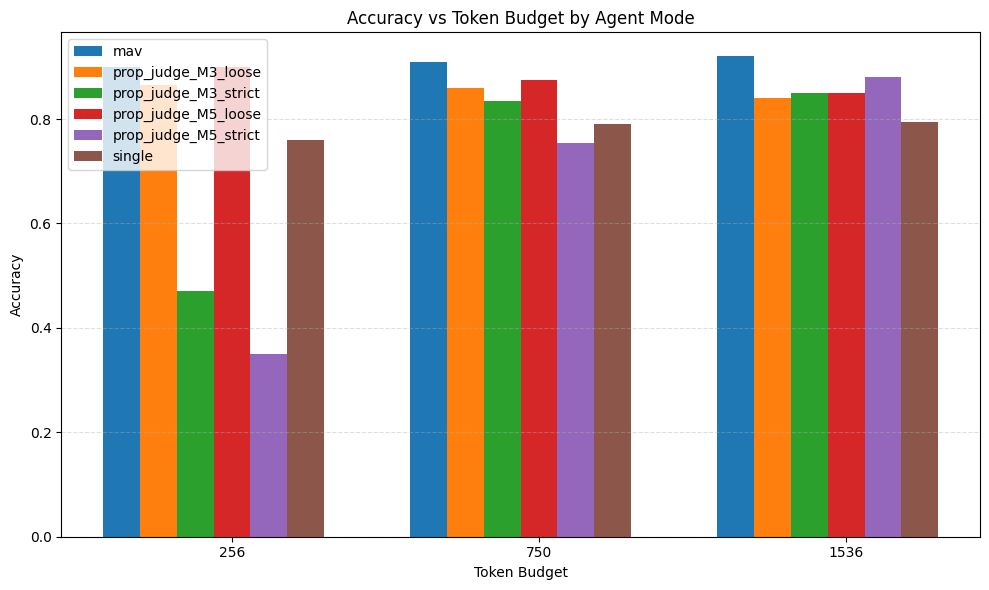

In [16]:
# ============================================
# BAR CHARTS FOR TOKEN-BUDGETED BENCHMARK
# ============================================
import matplotlib.pyplot as plt
import numpy as np

# Ensure consistent ordering

summary_sorted = summary_df.sort_values(["total_budget", "mode"])

# Unique budgets and modes
budgets = sorted(summary_sorted["total_budget"].unique())
modes = sorted(summary_sorted["mode"].unique())

# helper function to pivot for a metric
def pivot(metric):
    return summary_sorted.pivot(index="mode", columns="total_budget", values=metric).reindex(modes)

# Color palette
colors = plt.cm.tab20(np.linspace(0, 1, len(modes)))

# ============================
# ACCURACY BAR CHART
# ============================

acc_pivot = pivot("accuracy")

plt.figure(figsize=(10, 6))
bar_width = 0.12
x = np.arange(len(budgets))

for i, mode in enumerate(modes):
    plt.bar(x + i * bar_width, acc_pivot.loc[mode], width=bar_width, label=mode)

plt.xticks(x + bar_width * (len(modes) / 2), budgets)
plt.ylabel("Accuracy")
plt.xlabel("Token Budget")
plt.title("Accuracy vs Token Budget by Agent Mode")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


## Analysis Module: Accuracy, Error Reduction & Cost Metrics

This module loads the cleaned benchmark summary and computes the main quantitative indicators used to compare the single-agent baseline with the multi-agent architectures. For each token budget, we derive accuracy statistics (including 95% confidence bands), error reduction relative to the baseline, and computational cost metrics such as tokens per correct answer and seconds per correct answer.

We also calculate cost multipliers and a simple efficiency score to assess whether accuracy gains justify the additional compute. The resulting tables and budget level summaries provide the numerical foundation for the plots and for the final conclusions of the project.


In [14]:
# ============================================================
# ANALYSIS MODULE: accuracy, error reduction & cost trade-offs
# using benchmark_token_budget_summary_clean.csv
# ============================================================

import os
import numpy as np
import pandas as pd
from IPython.display import display

# ----------------------------------------
# Load summary CSV
# ----------------------------------------
CLEAN_CSV_PATH = os.path.join(CSV_DIR, "benchmark_token_budget_summary.csv")

summary_df = pd.read_csv(CLEAN_CSV_PATH)

# Make sure the expected columns exist, should not be necessary
required_cols = {
    "mode",
    "total_budget",
    "accuracy",
    "avg_tokens",
    "avg_latency_s",
    "tokens_per_correct",
    "secs_per_correct",
}
missing = required_cols - set(summary_df.columns)
# Good practice error message, in this case it should be needed at all
if missing:
    raise ValueError(f"CSV is missing the following columns: {missing}")

# Data cleaning in case there is any weird spaces
summary_df["mode"] = summary_df["mode"].astype(str).str.strip()

# ----------------------------------------
# Obtain basic metrics
# ----------------------------------------

BENCH_N = 200

df = summary_df.copy()

# Error rate
df["error_rate"] = 1.0 - df["accuracy"]

# Standard Error and CB95 for accuracy (binomial)
df["se_accuracy"] = np.sqrt(df["accuracy"] * (1 - df["accuracy"]) / BENCH_N)
df["ci95_low"] = (df["accuracy"] - 1.96 * df["se_accuracy"]).clip(0.0, 1.0)
df["ci95_high"] = (df["accuracy"] + 1.96 * df["se_accuracy"]).clip(0.0, 1.0)

# ----------------------------------------
# Relative comparison to the baseline
# ----------------------------------------

# Obtain baseline df
baseline_df = (
    df[df["mode"].str.contains("single", case=False)]
    .rename(
        columns={
            "accuracy": "acc_single",
            "error_rate": "err_single",
            "tokens_per_correct": "tpc_single",
            "secs_per_correct": "spc_single",
        }
    )[["total_budget", "acc_single", "err_single", "tpc_single", "spc_single"]]
)

# Not really needed but good practice
if baseline_df.empty:
    raise ValueError("No 'single' rows found in data.")

# Total_budget merge for same budget baseline comparison
enh = df.merge(baseline_df, on="total_budget", how="left", validate="many_to_one")

# Accuracy gains (absolute gain and relative to baseline gain)
enh["delta_acc"] = enh["accuracy"] - enh["acc_single"]
enh["delta_acc_pct"] = 100.0 * enh["delta_acc"] / enh["acc_single"]

# Relative Error Reduction: (err_single - err_mode) / err_single
enh["error_reduction_pct"] = 100.0 * (
    (enh["err_single"] - enh["error_rate"]) / enh["err_single"]
)

# Cost multipliers (tokens / tiempo) vs single
enh["tokens_multiplier"] = enh["tokens_per_correct"] / enh["tpc_single"]
enh["secs_multiplier"] = enh["secs_per_correct"] / enh["spc_single"]

# Efficiency trade off heuristic metric:
#   Accuracy % gain - Token penalization %
enh["efficiency_score"] = enh["delta_acc_pct"] - (enh["tokens_multiplier"] - 1.0) * 100.0

# sort for easier interpretation
enh_sorted = enh.sort_values(["total_budget", "mode"]).reset_index(drop=True)

# ----------------------------------------
# Console summary tables
# ----------------------------------------

cols_main = [
    "mode",
    "total_budget",
    "accuracy",
    "ci95_low",
    "ci95_high",
    "error_rate",
    "error_reduction_pct",
    "tokens_per_correct",
    "secs_per_correct",
    "tokens_multiplier",
    "secs_multiplier",
    "efficiency_score",
]

print("\n============================")
print("ADVANCED SUMMARY (BY ROW)")
print("============================")

# use only relevant columns
table = enh_sorted[cols_main].copy()

# apply .3f format to numeric columns
num_cols = table.select_dtypes(include="number").columns
fmt_dict = {c: "{:.3f}" for c in num_cols}

# Display it in HTML style in the console
display(table.style.format(fmt_dict))

# Matrix style (row = mode, columns = budget)
def pivot_matrix(df, value_col, fmt="{:7.3f}"):
    mat = df.pivot(index="mode", columns="total_budget", values=value_col)
    print(f"\n=== {value_col} (rows=mode, cols=budget) ===")
    mat_str = mat.map(lambda x: fmt.format(x) if pd.notnull(x) else "   nan")
    print(mat_str)

pivot_matrix(enh_sorted, "accuracy")
pivot_matrix(enh_sorted, "error_reduction_pct", fmt="{:7.2f}")
pivot_matrix(enh_sorted, "tokens_per_correct")
pivot_matrix(enh_sorted, "tokens_multiplier", fmt="{:7.2f}")
pivot_matrix(enh_sorted, "secs_multiplier", fmt="{:7.2f}")

# ----------------------------------------
# Generate a text summary, this will help build the report
# ----------------------------------------

def qualitative_label_improvement(delta_acc_pct: float) -> str:
    """Cualitative label"""
    if np.isnan(delta_acc_pct):
        return "no data"
    if delta_acc_pct < 2:
        return "very small"
    if delta_acc_pct < 5:
        return "small"
    if delta_acc_pct < 10:
        return "moderate"
    return "large"

def describe_budget(group: pd.DataFrame):
    """Prints a summary for a determined budget."""
    budget = group["total_budget"].iloc[0]
    print("\n====================================================")
    print(f" BUDGET = {budget} max_tokens")
    print("====================================================")

    # current budget baseline single results
    base = group[group["mode"].str.contains("single", case=False)].iloc[0]
    base_acc = base["accuracy"]
    base_err = base["error_rate"]
    base_tpc = base["tokens_per_correct"]
    base_spc = base["secs_per_correct"]

    print(
        f"Baseline (single): acc={base_acc:.3f} "
        f"[95% CI {base['ci95_low']:.3f}, {base['ci95_high']:.3f}], "
        f"error={base_err:.3f}, "
        f"tokens/ok={base_tpc:.1f}, secs/ok={base_spc:.2f}"
    )

    # Experimental architectures
    for _, row in group.sort_values("accuracy", ascending=False).iterrows():
        if row["mode"].lower().startswith("single"):
            continue  # baseline obtained previously

        mode = row["mode"]
        acc = row["accuracy"]
        err = row["error_rate"]
        ci_lo = row["ci95_low"]
        ci_hi = row["ci95_high"]
        d_acc = row["delta_acc_pct"]
        err_red = row["error_reduction_pct"]
        t_mult = row["tokens_multiplier"]
        s_mult = row["secs_multiplier"]
        eff = row["efficiency_score"]

        label = qualitative_label_improvement(d_acc)

        print(f"\n- {mode}:")
        print(
            f"    acc={acc:.3f} [95% CI {ci_lo:.3f}, {ci_hi:.3f}], "
            f"error={err:.3f}"
        )
        print(
            f"    -> accuracy change vs single: {d_acc:+.2f}% ({label} gain)"
        )
        print(
            f"    -> error reduction vs single: {err_red:+.2f}% "
            f"(relative decrease of error)"
        )
        print(
            f"    -> token cost: {t_mult:.2f}x tokens_per_correct "
            f"(baseline={base_tpc:.1f})"
        )
        print(
            f"    -> time cost:  {s_mult:.2f}x secs_per_correct "
            f"(baseline={base_spc:.2f})"
        )
        print(
            f"    -> efficiency_score (accuracy - token penalty): {eff:.2f}"
        )

# Execution of Summary for each budget
for budget, group in enh_sorted.groupby("total_budget"):
    describe_budget(group)


ADVANCED SUMMARY (BY ROW)


,mode,total_budget,accuracy,ci95_low,ci95_high,error_rate,error_reduction_pct,tokens_per_correct,secs_per_correct,tokens_multiplier,secs_multiplier,efficiency_score
0,mav,256.000,0.900,0.858,0.942,0.100,58.333,423.794,21.879,3.591,4.138,-240.707
1,prop_judge_M3_loose,256.000,0.865,0.818,0.912,0.135,43.750,329.543,16.317,2.793,3.086,-165.443
2,prop_judge_M3_strict,256.000,0.470,0.401,0.539,0.530,-120.833,326.436,17.329,2.766,3.278,-214.783
3,prop_judge_M5_loose,256.000,0.900,0.858,0.942,0.100,58.333,518.678,24.809,4.395,4.692,-321.112
4,prop_judge_M5_strict,256.000,0.350,0.284,0.416,0.650,-170.833,487.957,25.658,4.135,4.853,-367.447
5,single,256.000,0.760,0.701,0.819,0.240,0.000,118.007,5.287,1.000,1.000,0.000
6,mav,750.000,0.910,0.870,0.950,0.090,57.143,476.813,24.484,4.147,4.803,-299.499
7,prop_judge_M3_loose,750.000,0.860,0.812,0.908,0.140,33.333,331.047,16.567,2.879,3.250,-179.053
8,prop_judge_M3_strict,750.000,0.835,0.784,0.886,0.165,21.429,320.922,15.983,2.791,3.135,-173.413
9,prop_judge_M5_loose,750.000,0.875,0.829,0.921,0.125,40.476,535.177,26.854,4.654,5.268,-354.689



=== accuracy (rows=mode, cols=budget) ===
total_budget             256      750      1536
mode                                           
mav                     0.900    0.910    0.920
prop_judge_M3_loose     0.865    0.860    0.840
prop_judge_M3_strict    0.470    0.835    0.850
prop_judge_M5_loose     0.900    0.875    0.850
prop_judge_M5_strict    0.350    0.755    0.880
single                  0.760    0.790    0.795

=== error_reduction_pct (rows=mode, cols=budget) ===
total_budget             256      750      1536
mode                                           
mav                     58.33    57.14    60.98
prop_judge_M3_loose     43.75    33.33    21.95
prop_judge_M3_strict  -120.83    21.43    26.83
prop_judge_M5_loose     58.33    40.48    26.83
prop_judge_M5_strict  -170.83   -16.67    41.46
single                   0.00     0.00     0.00

=== tokens_per_correct (rows=mode, cols=budget) ===
total_budget             256      750      1536
mode                              

## Analysis of Accuracy, Error Reduction, and Cost Trade-offs

This section summarizes the main quantitative comparisons between the single-agent baseline and the multi-agent reasoning architectures under equivalent token budgets. Using the enriched results table (`enh_sorted`), we extract the configurations of interest and generate a set of diagnostic plots that highlight both performance improvements and their computational costs.

The following analyses are included:

### 1. Accuracy vs Token Budget (with 95% Confidence Bands)
This plot shows how accuracy evolves as the token budget increases. It allows us to evaluate whether multi-agent systems scale more efficiently with computational budget and whether they consistently outperform the single-agent baseline. Confidence intervals help illustrate statistical uncertainty given the 200-item evaluation size.

### 2. Error Reduction vs Token Budget
To make improvements interpretable, accuracy gains are expressed as **error reduction (%)** relative to the single-agent baseline. This emphasizes not only raw performance but also how much better each architecture is at reducing mistakes per budget level.

### 3. Token Cost vs Error Reduction Trade-off
Here we examine the ratio between total tokens consumed and accuracy gains. This provides a view of **efficiency**, making noticeable the higher needs of computation by multi-agent architectures. The plot highlights regions where multi-agent setups deliver meaningful improvements without disproportionate increases in token usage.

### 4. Time Cost vs Error Reduction Trade-off
Analogous to the token analysis, this comparison evaluates runtime (seconds per correct answer) relative to accuracy improvements. It is particularly useful for understanding practical deployment trade-offs, since multi-agent strategies may increase latency because of its sequential structure.

---

Collectively, these plots could offer a comprehensive view of the performance–cost landscape and help identify which architectures provide the best balance between improved accuracy and computational efficiency. This analysis directly supports the report’s conclusions by quantifying both the absolute and relative benefits of the evaluated multi-agent methods.

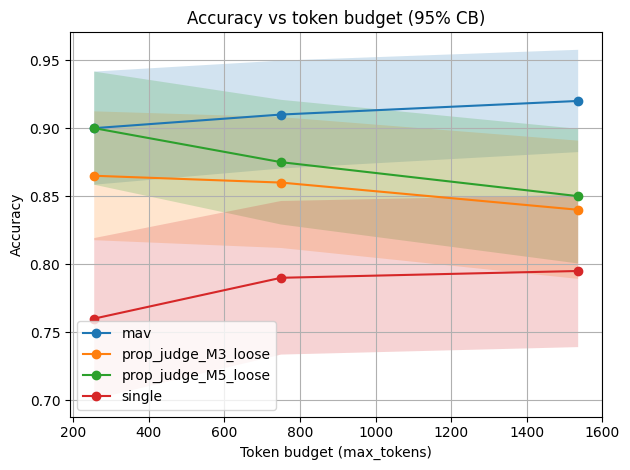

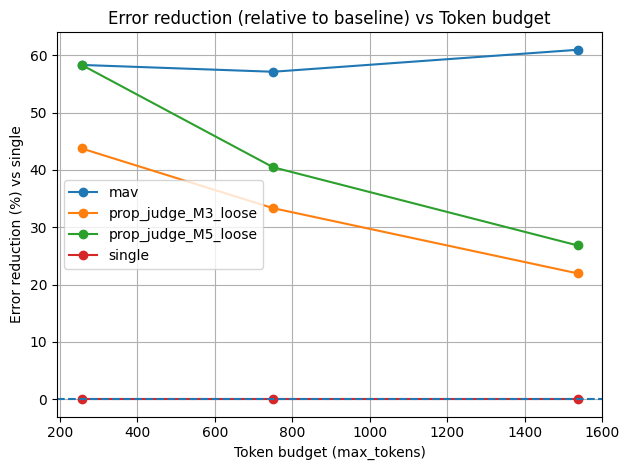

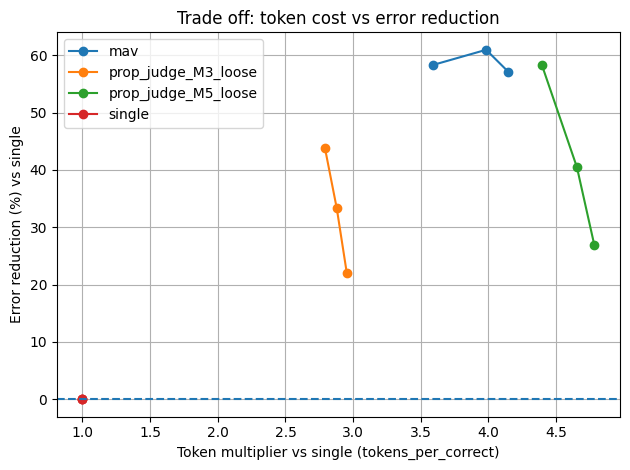

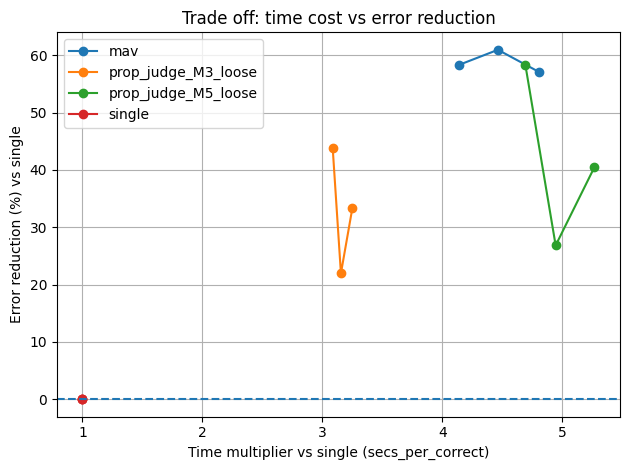

In [28]:
# ============================================
# Accuracy and Error Reduction Plots, the most useful for the report
# ============================================
import matplotlib.pyplot as plt

# Use the already enriched data frame
plot_df_all = enh_sorted.copy()

# Only these modes will be used as the Strict judge seems to be a suboptimal instrument
modes_plot = [
    "single",
    "mav",
    "prop_judge_M3_loose",
    "prop_judge_M5_loose",
]

plot_df = plot_df_all[plot_df_all["mode"].isin(modes_plot)].copy()
plot_df = plot_df.sort_values(["mode", "total_budget"])

# Budgets should be sorted correctly
budgets = sorted(plot_df["total_budget"].unique())

# ============================================================
# Accuracy vs Token Budget (with 95% Confidence Bands)
# ============================================================

plt.figure()
for mode, g in plot_df.groupby("mode"):
    g = g.sort_values("total_budget")
    plt.plot(g["total_budget"], g["accuracy"], marker="o", label=mode)
    # Plot with confidence band of 95%
    plt.fill_between(
        g["total_budget"],
        g["ci95_low"],
        g["ci95_high"],
        alpha=0.2,
    )

plt.xlabel("Token budget (max_tokens)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs token budget (95% CB)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "accuracy_vs_token_budget.pdf"))
plt.show()

# ============================================================
# Error reduction (with single as baseline) vs token budget
# ============================================================

plt.figure()
for mode, g in plot_df.groupby("mode"):
    g = g.sort_values("total_budget")
    plt.plot(
        g["total_budget"],
        g["error_reduction_pct"],
        marker="o",
        label=mode,
    )

plt.axhline(0.0, linestyle="--")  # line where there is no gain against baseline
plt.xlabel("Token budget (max_tokens)")
plt.ylabel("Error reduction (%) vs single")
plt.title("Error reduction (relative to baseline) vs Token budget")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "token_cost_vs_error_reduction.pdf"))
plt.show()

# ============================================================
# Trade off between token cost vs error reduction
# ============================================================

plt.figure()
for mode, g in plot_df.groupby("mode"):
    g = g.sort_values("tokens_multiplier")
    plt.plot(
        g["tokens_multiplier"],
        g["error_reduction_pct"],
        marker="o",
        label=mode,
    )

plt.axhline(0.0, linestyle="--")
plt.xlabel("Token multiplier vs single (tokens_per_correct)")
plt.ylabel("Error reduction (%) vs single")
plt.title("Trade off: token cost vs error reduction")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "tokens_vs_error_tradeoff.pdf"))
plt.show()

# ============================================================
# Trade off between time cost vs error reduction
# ============================================================

plt.figure()
for mode, g in plot_df.groupby("mode"):
    g = g.sort_values("secs_multiplier")
    plt.plot(
        g["secs_multiplier"],
        g["error_reduction_pct"],
        marker="o",
        label=mode,
    )

plt.axhline(0.0, linestyle="--")
plt.xlabel("Time multiplier vs single (secs_per_correct)")
plt.ylabel("Error reduction (%) vs single")
plt.title("Trade off: time cost vs error reduction")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "time_vs_error_tradeoff.pdf"))
plt.show()

## Interpretation of Results

All multi-agent architectures improve over the single-agent baseline across every token budget. MAV achieves the highest accuracies overall, reducing error by roughly 55–60% compared to the baseline and showing consistent gains at all compute levels.

The loose Proposer+Judge variants (M=3 and M=5) also provide meaningful improvements, typically achieving 20–45% error reduction, though they do not reach MAV’s performance. Increasing the number of proposers from 3 to 5 does not provide clear additional benefits.

These gains come at a higher computational cost: MAV is the most expensive in both tokens and latency, while the loose judge setups offer a smaller but more efficient improvement. The single agent remains the cheapest but consistently the least accurate.

In summary, multi-agent collaboration reliably improves GSM8K reasoning performance, with MAV offering the strongest accuracy gains as well as error reduction and the loose Proposer+Judge variants providing a more cost balanced alternative.


NOTE: this will be analyzed and interpreted further in the complete and partial reports.

In [25]:
# ============================================
# Compact table for latex
# ============================================

modes_interes = [
    "single",
    "mav",
    "prop_judge_M3_loose",
    "prop_judge_M5_loose",
]

cols_focus = [
    "mode",
    "total_budget",
    "accuracy",
    "ci95_low",
    "ci95_high",
    "error_rate",
    "error_reduction_pct",
    "tokens_per_correct",
    "secs_per_correct",
]

df_focus = (
    enh_sorted[enh_sorted["mode"].isin(modes_interes)][cols_focus]
    .sort_values(["total_budget", "mode"])
    .reset_index(drop=True)
)

# Export LaTeX table
latex_str = df_focus.to_latex(
    index=False,
    float_format="%.3f",
    escape=True,
    column_format="lcccccccc"
)

with open("table_main_results.tex", "w") as f:
    f.write(latex_str)

print("Saved LaTeX table to table_main_results.tex")

Saved LaTeX table to table_main_results.tex
